## Импорты и подготовка данных

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from prefixspan import PrefixSpan
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

df = pd.read_excel("../data/online_retail.xlsx")  # загружаем датасет

df = df.dropna(subset=["Customer ID"])  # убираем строки без клиента
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]  
df["Customer ID"] = df["Customer ID"].astype(int)  # приводим id к целому числу
df["StockCode"] = df["StockCode"].astype(str)  # приводим код товара к строке
df = df.sort_values(["Customer ID", "InvoiceDate"])  # сортируем по клиенту и дате

# группируем товары внутри одной транзакции
transactions = df.groupby(["Customer ID", "Invoice"])["StockCode"].apply(list).reset_index()

# группируем транзакции по клиентам — получаем последовательности
sequences = transactions.groupby("Customer ID")["StockCode"].apply(list).reset_index()
sequences.columns = ["client_id", "sequence"]

print(f"клиентов: {len(sequences)}, пример последовательности:")
print(sequences["sequence"].iloc[0][:3])

клиентов: 4312, пример последовательности:
[['TEST001'], ['TEST001'], ['TEST001']]


## Задание 1. Реализация AprioriAll

In [3]:
# проверяет, является ли candidate подпоследовательностью sequence
def is_subsequence(candidate, sequence):
    idx = 0
    for itemset in sequence:
        if set(candidate[idx]).issubset(set(itemset)):
            idx += 1
            if idx == len(candidate):
                return True
    return False

# основной алгоритм aprioriall — ищет все частые последовательности
def apriori_all(sequences_df, min_sup=0.5):
    seqs = sequences_df["sequence"].tolist()
    n = len(seqs)# общее количество клиентов
    
    # ищем только последовательности длины 1
    item_counts = defaultdict(int)
    for seq in seqs:
        unique = set(item for itemset in seq for item in itemset)  # уникальные товары клиента
        for item in unique:
            # сколько клиентов купили этот товар хотя бы раз
            item_counts[((item,),)] += 1

    L1 = {seq: cnt/n for seq, cnt in item_counts.items() if cnt/n >= min_sup}  # частые 1-последовательности
    frequent = [L1]
    # ищем длинные последовательности 1+
    while True:
        prev = list(frequent[-1].keys())
        candidates = set()

        for s1 in prev:
            for s2 in prev:
                if s1[1:] == s2[:-1]:  
                    candidates.add(s1 + (s2[-1],))

        new_level = {}
        for cand in candidates:
            cnt = sum(1 for seq in seqs if is_subsequence(cand, seq))  # считаем поддержку
            sup = cnt / n
            if sup >= min_sup:
                new_level[cand] = sup

        if not new_level:
            break
        frequent.append(new_level)

    return frequent

# синтетический пример для проверки корректности алгоритма
synthetic = pd.DataFrame({
    "client_id": [1, 2, 3],
    "sequence": [
        [['A'], ['B'], ['C']],
        [['A'], ['C']],
        [['A'], ['B']]
    ]
})

result = apriori_all(synthetic, min_sup=0.66)

for level_num, level in enumerate(result, start=1):
    print(f"\nдлина {level_num}:")
    for seq, sup in sorted(level.items(), key=lambda x: -x[1]):
        print(f"  {seq} -> support = {round(sup, 2)}")


длина 1:
  (('A',),) -> support = 1.0
  (('C',),) -> support = 0.67
  (('B',),) -> support = 0.67

длина 2:
  (('A',), ('C',)) -> support = 0.67
  (('A',), ('B',)) -> support = 0.67


## Задание 2.1 Влияние min_sup

min_sup=0.05: найдено 578 шаблонов
min_sup=0.1: найдено 76 шаблонов
min_sup=0.2: найдено 3 шаблонов


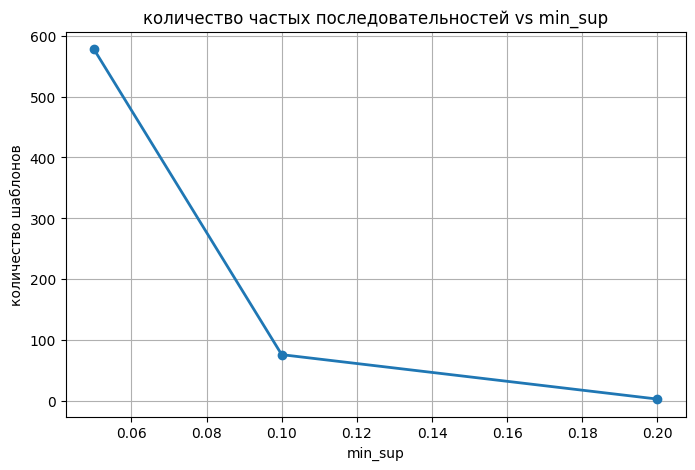

In [24]:
# берём только первые 500 клиентов для ускорения
sequences_small = sequences.head(500).reset_index(drop=True)

min_sups = [0.05, 0.1, 0.2]
counts = []

for ms in min_sups:
    freq = apriori_all(sequences_small, min_sup=ms)
    total = sum(len(level) for level in freq)
    counts.append(total)
    print(f"min_sup={ms}: найдено {total} шаблонов")

plt.figure(figsize=(8, 5))
plt.plot(min_sups, counts, marker="o", linewidth=2)
plt.title("количество частых последовательностей vs min_sup")
plt.xlabel("min_sup")
plt.ylabel("количество шаблонов")
plt.grid(True)
plt.show()

## Задание 2.2 Сравнение с ассоциативными правилами

In [26]:
# разворачиваем последовательности в плоский список товаров для каждого клиента
flat_transactions = sequences["sequence"].apply(
    lambda x: list(set(item for itemset in x for item in itemset))
)

te = TransactionEncoder()

te_ary = te.fit(flat_transactions).transform(flat_transactions)   # делаем матрицу True/False (купил/не купил)
basket = pd.DataFrame(te_ary, columns=te.columns_)

freq_items = apriori(basket, min_support=0.1, use_colnames=True)  # ищем частые наборы
rules = association_rules(freq_items, metric="lift", min_threshold=1.0)  # строим правила

top3 = rules.sort_values("lift", ascending=False).head(3)  # топ-3 правила по lift
print("топ-3 ассоциативных правила по lift:")
print(top3[["antecedents", "consequents", "support", "confidence", "lift"]])

# проверяем, являются ли топ-3 правила частыми последовательностями
freq_seqs = apriori_all(sequences, min_sup=0.1)
all_patterns = [seq for level in freq_seqs for seq in level.keys()]

print("\nпроверка вхождения в частые последовательности:")
for _, row in top3.iterrows():
    a = list(row["antecedents"])[0]
    b = list(row["consequents"])[0]
    pattern = ((a,), (b,))
    found = pattern in all_patterns
    print(f"  {a} -> {b}: {'найдено' if found else 'не найдено'} в последовательностях")

топ-3 ассоциативных правила по lift:
           antecedents          consequents   support  confidence      lift
0   frozenset({21733})  frozenset({85123A})  0.108071    0.848816  3.207796
1  frozenset({85123A})   frozenset({21733})  0.108071    0.408414  3.207796

проверка вхождения в частые последовательности:
  21733 -> 85123A: не найдено в последовательностях
  85123A -> 21733: не найдено в последовательностях


## Задание 2. Временные окна (max_gap)

In [4]:
def build_sequences_with_gap(df, max_days=None):
    df = df.sort_values(["Customer ID", "InvoiceDate"])
    result = []

    for client_id, group in df.groupby("Customer ID"):
        group = group.sort_values("InvoiceDate")
        client_seq = [] # глобальная история текущего клиента
        prev_invoice = None # номер предыдущего чека
        prev_date = None # дата предыдущего чека 
        current_trans = [] # товары, которые клиент складывает в корзину в данный момент

        for _, row in group.iterrows():
            if prev_invoice is None or row["Invoice"] != prev_invoice:
                # новая транзакция
                if max_days is not None and prev_date is not None:
                     # считаем разницу в днях между текущим чеком и предыдущим
                    gap = (row["InvoiceDate"] - prev_date).days
                    if gap > max_days:  # разрыв слишком большой — пропускаем
                        if current_trans:
                            client_seq.append(current_trans)  # cохраняем то, что накопили до разрыва
                        current_trans = []
                if current_trans:   # cохраняем предыдущий собранный чек в общую историю клиента
                    client_seq.append(current_trans)
                current_trans = [row["StockCode"]] # начинаем собирать новый чек (кладем туда первый товар)
                # запоминаем дату и номер текущего чека для следующего круга
                prev_date = row["InvoiceDate"]
                prev_invoice = row["Invoice"]
            else:
                current_trans.append(row["StockCode"])

        if current_trans:
            client_seq.append(current_trans)
        if client_seq:
            result.append({"client_id": client_id, "sequence": client_seq})

    return pd.DataFrame(result)

seq_no_gap = build_sequences_with_gap(df, max_days=None)  # берем всю историю клиентов 
seq_gap7 = build_sequences_with_gap(df, max_days=7)  # max_gap = 7 дней, делим историю пополам

# ищем шаблоны, которые встречаются у 10% людей
freq_no_gap = apriori_all(seq_no_gap, min_sup=0.1)
freq_gap7 = apriori_all(seq_gap7, min_sup=0.1)

# вытаскиваем шаблоны
patterns_no_gap = set(seq for level in freq_no_gap for seq in level.keys())
patterns_gap7 = set(seq for level in freq_gap7 for seq in level.keys())

# шаблоны которые исчезают при max_gap=7
disappeared = patterns_no_gap - patterns_gap7
appeared = patterns_gap7 - patterns_no_gap

print(f"без ограничения: {len(patterns_no_gap)} шаблонов")
print(f"max_gap=7: {len(patterns_gap7)} шаблонов")
print(f"\nисчезло шаблонов: {len(disappeared)}")
print(f"появилось новых: {len(appeared)}")

if disappeared:
    print("\nпримеры исчезнувших шаблонов:")
    for p in list(disappeared)[:3]:
        print(" ", p)

без ограничения: 40 шаблонов
max_gap=7: 40 шаблонов

исчезло шаблонов: 0
появилось новых: 0


## Задание 2.4 Граф переходов товаров

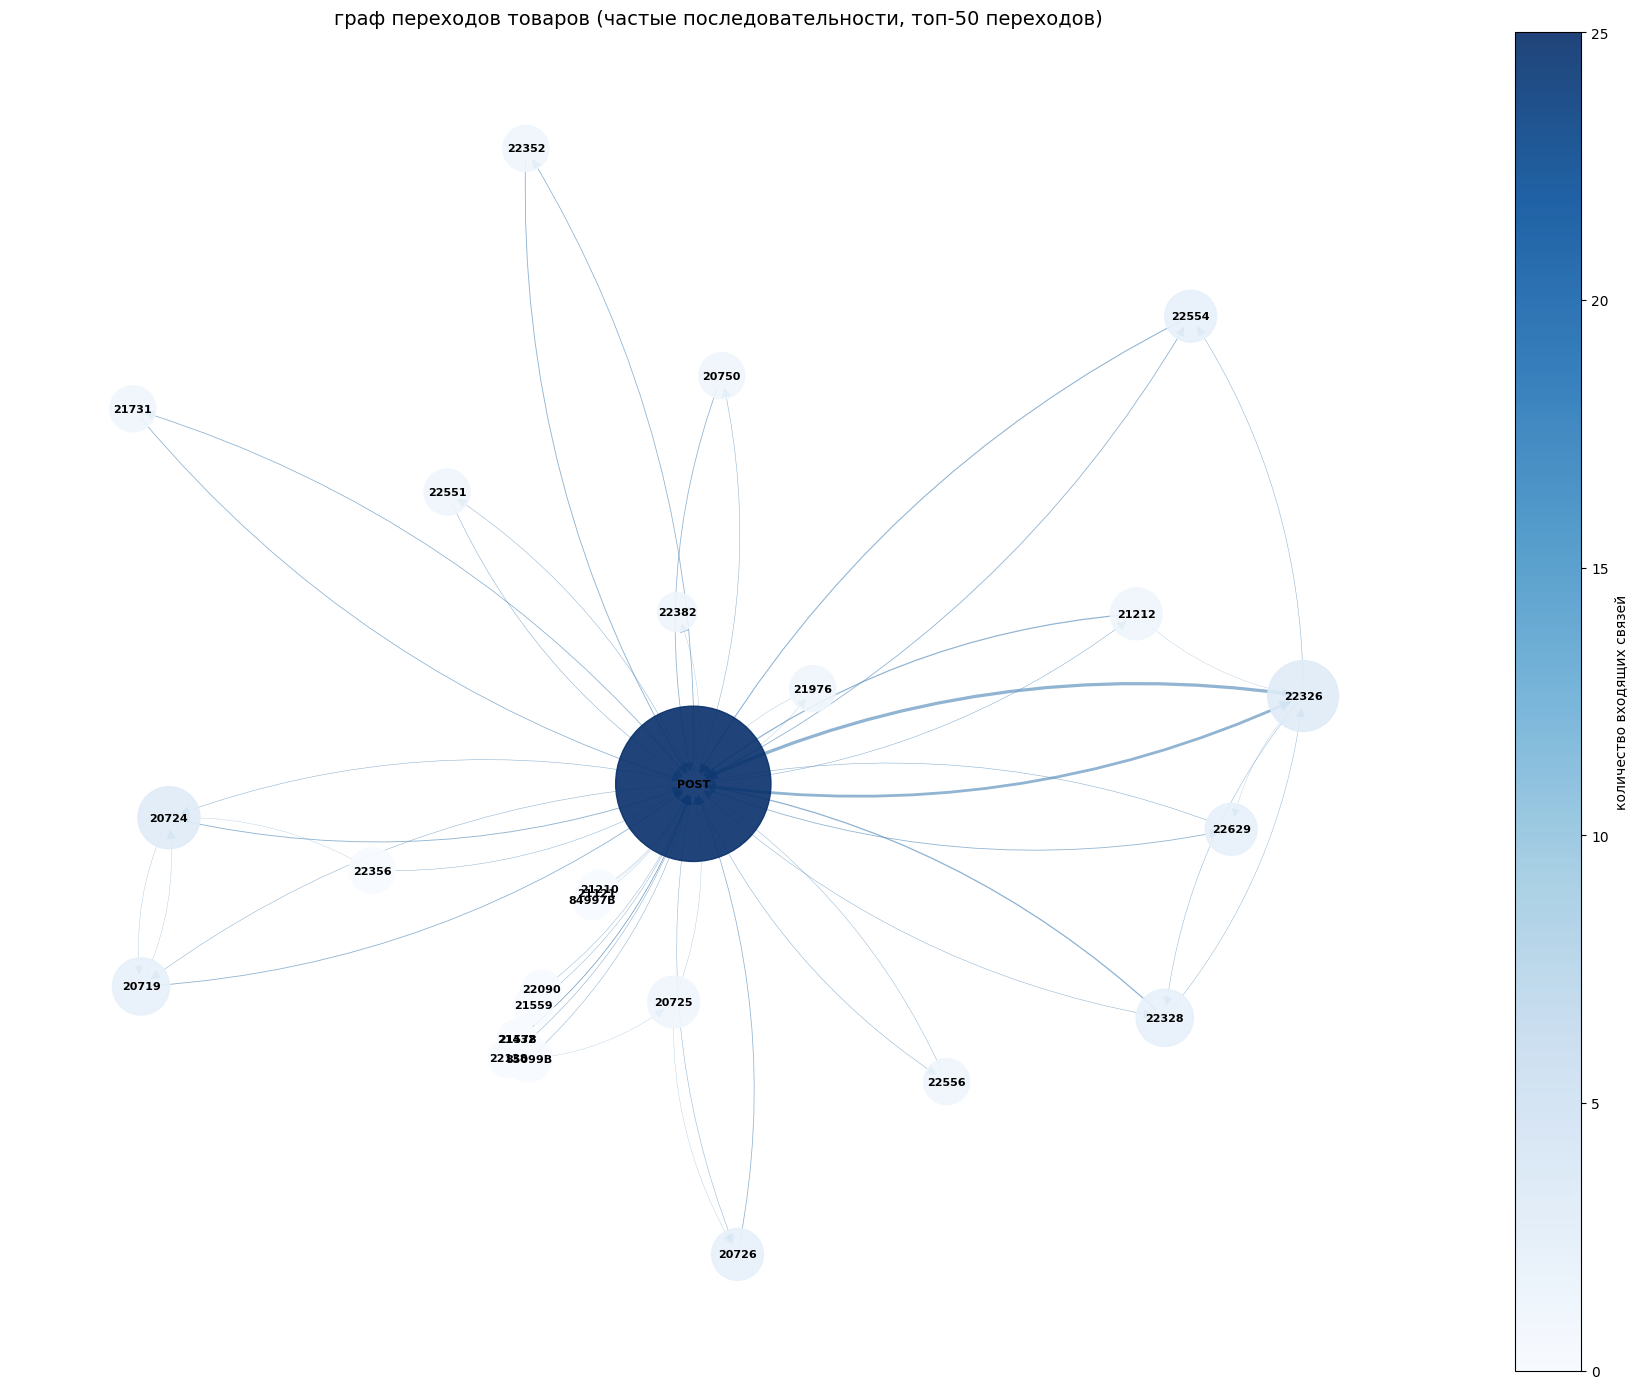


узлов в графе: 27
рёбер в графе: 50

топ-5 переходов:
  22326 -> POST, поддержка=0.77
  POST -> 22326, поддержка=0.67
  22328 -> POST, поддержка=0.308
  21212 -> POST, поддержка=0.292
  22554 -> POST, поддержка=0.256


In [38]:
freq = apriori_all(sequences_small, min_sup=0.05)  # берём min_sup пониже чтобы связей было больше
long_patterns = {seq: sup for level in freq[1:] for seq, sup in level.items() if len(seq) >= 2}

G = nx.DiGraph() # создаем направленный граф 

for pattern, sup in long_patterns.items():
    for i in range(len(pattern) - 1):
        src = pattern[i][0]
        dst = pattern[i+1][0]
        if src != dst:  # убираем петли
            if G.has_edge(src, dst):
                G[src][dst]["weight"] += sup
            else:
                G.add_edge(src, dst, weight=sup)

# берём топ-50 рёбер для большего количества связей
edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:50]
G_clean = nx.DiGraph()
G_clean.add_edges_from([(u, v, d) for u, v, d in edges_sorted])

plt.figure(figsize=(18, 14))
pos = nx.kamada_kawai_layout(G_clean)  # даёт красивое равномерное расположение

# размер узла зависит от степени (чем больше связей — тем крупнее)
node_degrees = dict(G_clean.degree())
node_sizes = [500 + node_degrees[n] * 300 for n in G_clean.nodes()]

# цвет узла зависит от числа входящих рёбер
in_degrees = dict(G_clean.in_degree())
node_colors = [in_degrees[n] for n in G_clean.nodes()]

weights = [G_clean[u][v]["weight"] * 3 for u, v in G_clean.edges()]

nodes = nx.draw_networkx_nodes(G_clean, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.Blues,
    alpha=0.9)

nx.draw_networkx_labels(G_clean, pos, font_size=8, font_color="black", font_weight="bold")

nx.draw_networkx_edges(G_clean, pos,
    width=weights,
    edge_color="steelblue",
    alpha=0.6,
    arrows=True,
    arrowsize=15,
    connectionstyle="arc3,rad=0.15")  # небольшой изгиб рёбер чтобы не сливались

plt.colorbar(nodes, label="количество входящих связей")
plt.title("граф переходов товаров (частые последовательности, топ-50 переходов)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"\nузлов в графе: {G_clean.number_of_nodes()}")
print(f"рёбер в графе: {G_clean.number_of_edges()}")
print("\nтоп-5 переходов:")
for u, v, d in edges_sorted[:5]:
    print(f"  {u} -> {v}, поддержка={round(d['weight'], 3)}")

## Задание 3. Сравнение AprioriAll и PrefixSpan

In [35]:
# преобразуем последовательности в плоский формат для prefixspan
seqs_list_flat = [
    [item for itemset in seq for item in itemset]  # разворачиваем вложенные списки
    for seq in sequences_small["sequence"].tolist()
]

ps = PrefixSpan(seqs_list_flat)
start = time.time()
min_sup_count = int(0.1 * len(seqs_list_flat))
freq_ps = ps.frequent(min_sup_count)
time_ps = time.time() - start

start = time.time()
freq_ap = apriori_all(sequences_small, min_sup=0.1)
time_ap = time.time() - start

count_ap = sum(len(level) for level in freq_ap)
count_ps = len(freq_ps)

print(f"{'алгоритм':<20} {'время (сек)':<15} {'шаблонов':<15} {'примечание'}")
print("-" * 60)
print(f"{'AprioriAll':<20} {round(time_ap, 2):<15} {count_ap:<15} наша реализация")
print(f"{'PrefixSpan':<20} {round(time_ps, 2):<15} {count_ps:<15} готовая библиотека")
print(f"\nprefixspan быстрее в {round(time_ap / time_ps, 1)} раза")

алгоритм             время (сек)     шаблонов        примечание
------------------------------------------------------------
AprioriAll           10.64           76              наша реализация
PrefixSpan           0.44            89              готовая библиотека

prefixspan быстрее в 24.4 раза


## Задание 4. Предсказание следующего события

In [30]:
# разделяем по времени: 80% на обучение, 20% на тест
split_idx = int(len(sequences) * 0.8)
train = sequences.iloc[:split_idx].reset_index(drop=True)
test = sequences.iloc[split_idx:].reset_index(drop=True)

freq_train = apriori_all(train, min_sup=0.1)  # частые последовательности на train

# строим словарь: последний элемент -> следующий рекомендуемый
next_item_map = {} 
for level in freq_train[1:]:  # берём только длину >= 2
    for seq, sup in level.items():
        prefix = seq[-2]  # предпоследний элемент
        next_item = seq[-1]  # следующий элемент
          # запоминаем переход с максимальной вероятностью (sup)
        if prefix not in next_item_map or next_item_map[prefix][1] < sup:
            next_item_map[prefix] = (next_item, sup)  # сохраняем с максимальной поддержкой

# базовый подход: самый частый товар
all_items = [item for seq in train["sequence"] for itemset in seq for item in itemset]
most_popular = max(set(all_items), key=all_items.count)

correct_seq = 0  # точность нашей модели
correct_base = 0  # точность базового подхода

for _, row in test.iterrows():
    seq = row["sequence"]
    if len(seq) < 2:
        continue
    last = seq[-2][0] if seq[-2] else None  # последний известный элемент
    actual = set(seq[-1])  # реальная следующая транзакция

    pred_seq = next_item_map.get((last,), (None,))[0]  # предсказание модели
    if pred_seq and pred_seq[0] in actual:
        correct_seq += 1
    if most_popular in actual:
        correct_base += 1

n_test = len(test[test["sequence"].apply(len) >= 2])
print(f"accuracy@1 (aprioriall): {round(correct_seq/n_test, 3)}")
print(f"accuracy@1 (топ-товар):  {round(correct_base/n_test, 3)}")
print(f"\nучёт последовательности {'улучшает' if correct_seq > correct_base else 'не улучшает'} точность")

accuracy@1 (aprioriall): 0.004
accuracy@1 (топ-товар):  0.127

учёт последовательности не улучшает точность


## Задание 5. Контрастные последовательности

highvalue: 200, lowvalue: 200

топ-5 контрастных последовательностей (highvalue):
    pattern  sup_high  sup_low  contrast
((22423,),)     0.355      0.0     0.355
((20724,),)     0.310      0.0     0.310
((22382,),)     0.305      0.0     0.305
((20685,),)     0.285      0.0     0.285
((22629,),)     0.285      0.0     0.285


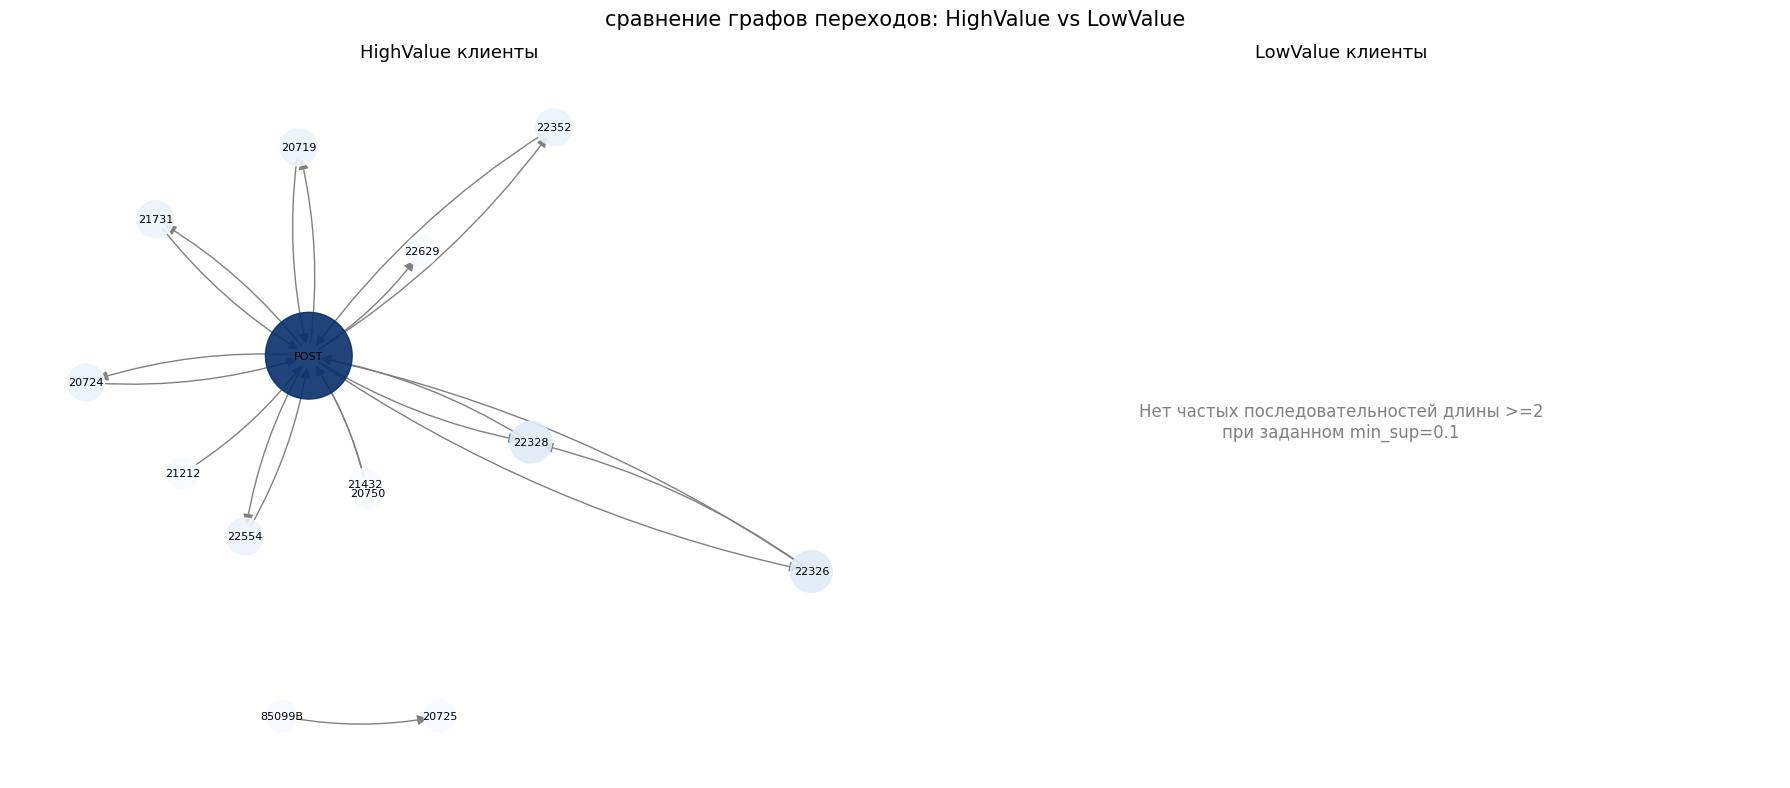


гипотеза:
Клиенты, которые купили 85099B, а затем 85099B,
с большей вероятностью являются высокодоходными.


In [37]:
# суммарная выручка каждого клиента 
client_revenue = df.groupby("Customer ID").apply(
    lambda x: (x["Quantity"] * x["Price"]).sum()
).reset_index()
client_revenue.columns = ["client_id", "revenue"]

threshold = client_revenue["revenue"].quantile(0.75)
high_clients = client_revenue[client_revenue["revenue"] >= threshold]["client_id"] # VIP
low_clients = client_revenue[client_revenue["revenue"] < threshold]["client_id"] # обычные (75%)

# находим частые последовательности для VIP и для обычных отдельно
high_seq = sequences[sequences["client_id"].isin(high_clients)].head(200).reset_index(drop=True)
low_seq = sequences[sequences["client_id"].isin(low_clients)].head(200).reset_index(drop=True)

print(f"highvalue: {len(high_seq)}, lowvalue: {len(low_seq)}")

# ищем частые последовательности
freq_high = apriori_all(high_seq, min_sup=0.1)
freq_low = apriori_all(low_seq, min_sup=0.1)

high_patterns = {seq: sup for level in freq_high for seq, sup in level.items()}
low_patterns = {seq: sup for level in freq_low for seq, sup in level.items()}

# считаем контрастность
contrast = []
for seq, sup_h in high_patterns.items():
    sup_l = low_patterns.get(seq, 0)
    # насколько чаще этот паттерн встречается у богатых, чем у бедных?
    contrast.append({"pattern": seq, "sup_high": sup_h, "sup_low": sup_l, "contrast": sup_h - sup_l})

contrast_df = pd.DataFrame(contrast).sort_values("contrast", ascending=False)
print("\nтоп-5 контрастных последовательностей (highvalue):")
print(contrast_df.head(5).to_string(index=False))

# графы
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, seq_data, title, color in zip(
    axes,
    [high_seq, low_seq],
    ["HighValue клиенты", "LowValue клиенты"],
    ["Blues", "Oranges"]
):
    G = nx.DiGraph()
    freq = apriori_all(seq_data, min_sup=0.1)
    
    # берем паттерны длины >= 2. условие len(freq) > 1 нужно, чтобы не было ошибки, если есть только длина 1
    if len(freq) > 1:
        patterns = {seq: sup for level in freq[1:] for seq, sup in level.items() if len(seq) >= 2}
        
        for pattern, sup in patterns.items():
            for i in range(len(pattern) - 1):
                src = pattern[i][0]
                dst = pattern[i+1][0]
                if src != dst:
                    if G.has_edge(src, dst):
                        G[src][dst]["weight"] += sup
                    else:
                        G.add_edge(src, dst, weight=sup)

    # поверяем, есть ли ребра. Если нет - пишем текст.
    if len(G.edges()) == 0:
        ax.text(0.5, 0.5, "Нет частых последовательностей длины >=2\nпри заданном min_sup=0.1", 
                ha='center', va='center', fontsize=12, color='gray')
        ax.set_title(title, fontsize=13)
        ax.axis("off")
        continue

    top_edges = sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:20]
    G_top = nx.DiGraph()
    G_top.add_edges_from([(u, v, d) for u, v, d in top_edges])

    pos = nx.kamada_kawai_layout(G_top)
    degrees = dict(G_top.degree())
    sizes = [300 + degrees.get(n, 0) * 200 for n in G_top.nodes()]

    nx.draw_networkx_nodes(G_top, pos, ax=ax, node_size=sizes,
                           node_color=list(degrees.values()), cmap=getattr(plt.cm, color), alpha=0.9)
    nx.draw_networkx_labels(G_top, pos, ax=ax, font_size=8)
    nx.draw_networkx_edges(G_top, pos, ax=ax, arrows=True,
                           edge_color="gray", arrowsize=15, connectionstyle="arc3,rad=0.1")
    ax.set_title(title, fontsize=13)
    ax.axis("off")

plt.suptitle("сравнение графов переходов: HighValue vs LowValue", fontsize=15)
plt.tight_layout()
plt.show()

print("\nгипотеза:")
# фильтруем датафрейм, оставляем только шаблоны длины 2 и более
contrast_len2 = contrast_df[contrast_df["pattern"].apply(len) >= 2]

if not contrast_len2.empty and contrast_len2["contrast"].iloc[0] > 0:
    top_pat = contrast_len2["pattern"].iloc[0]
    # теперь безопасно брать индексы 0 и 1
    print(f"Клиенты, которые купили {top_pat[0][0]}, а затем {top_pat[1][0]},")
    print("с большей вероятностью являются высокодоходными.")
else:
    print("Нет выраженных контрастных последовательностей из 2-х и более товаров.")